In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv('Student_Performance.csv')

In [4]:
print("Student Data Preview:")
display(df.head())

Student Data Preview:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

In [6]:
print("data prossesing :")
print(df[['Extracurricular Activities']].head())

data prossesing :
   Extracurricular Activities
0                           1
1                           0
2                           1
3                           1
4                           0


In [7]:
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total Records: {len(df)}")
print(f"Training set: {len(X_train)} | Testing set: {len(X_test)}")

Total Records: 10000
Training set: 8000 | Testing set: 2000


In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_pred = model.predict(X_test)

In [11]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [12]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Accuracy: {r2:.2f}")

Mean Squared Error: 4.08
R-squared Accuracy: 0.99


In [13]:
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print("\nSample Results:")
print(results.head())


Sample Results:
   Actual  Predicted
0    51.0  54.711854
1    20.0  22.615513
2    46.0  47.903145
3    28.0  31.289767
4    41.0  43.004570


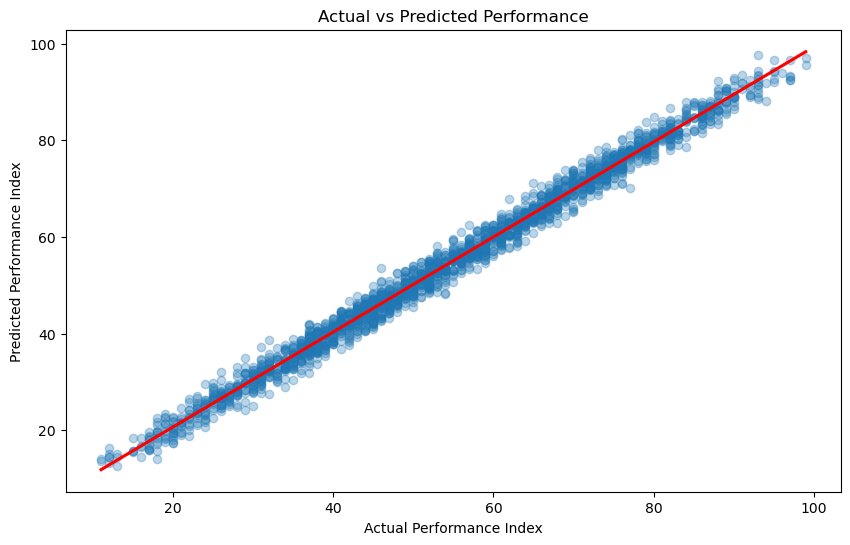

In [14]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Actual vs Predicted Performance')
plt.show()